In [79]:
df.to_csv(
    "cleaned_retail.csv",
    index=False
)

In [80]:
rfm.to_csv(
    "rfm_table.csv"
)

In [81]:
rfm.to_csv(
    "customer_segments.csv"
)

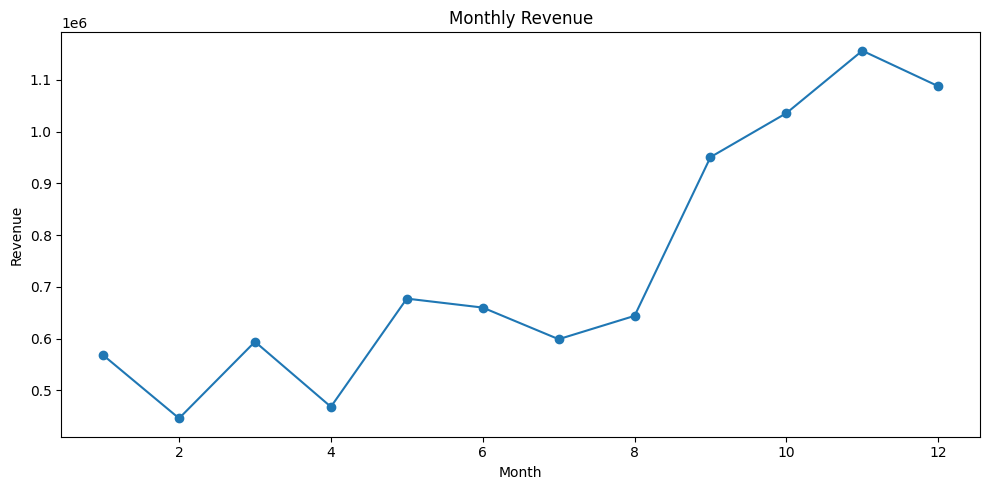

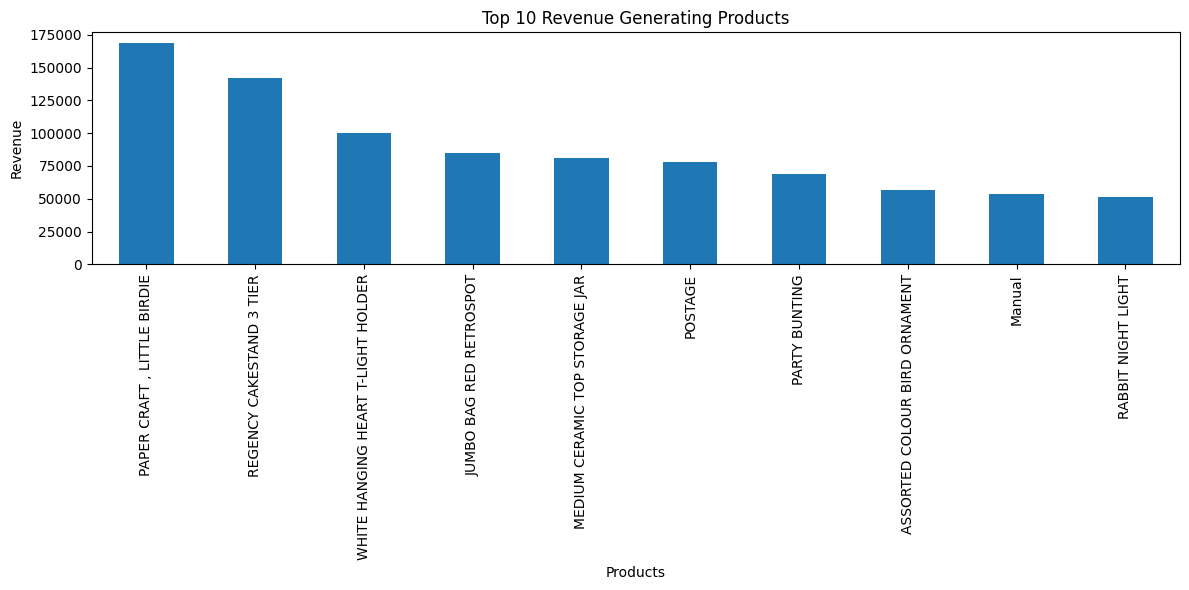

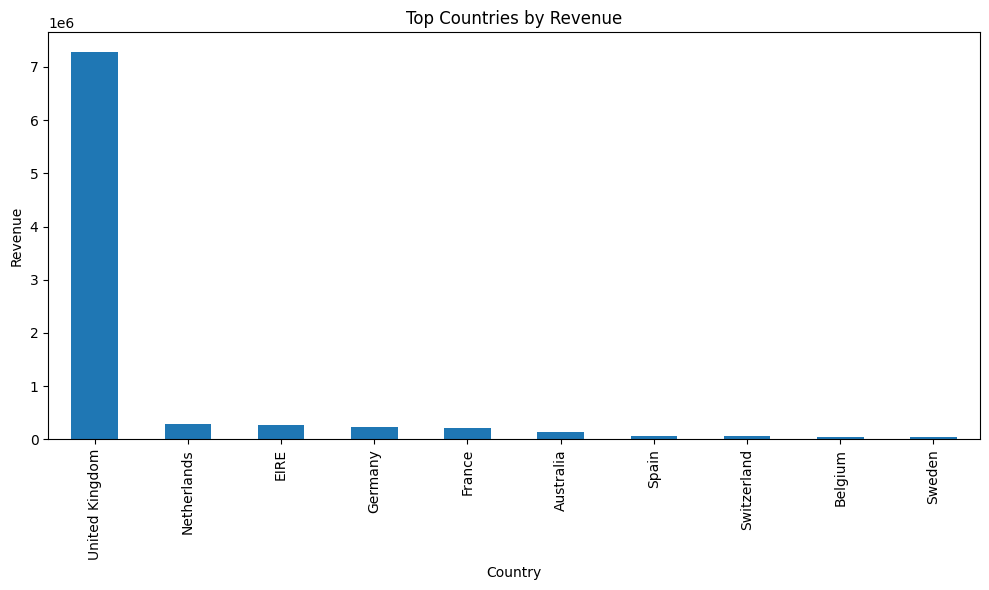

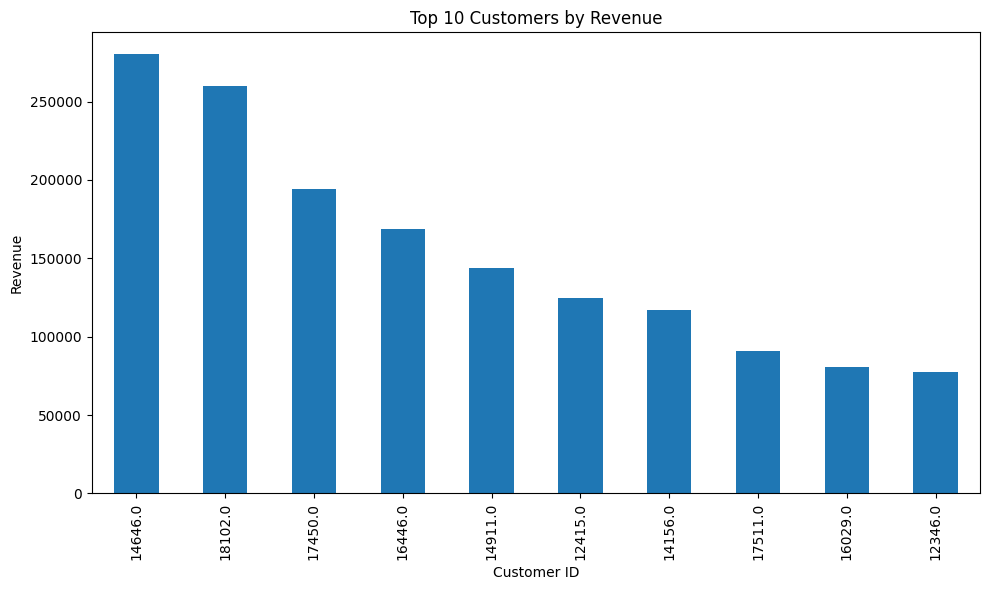

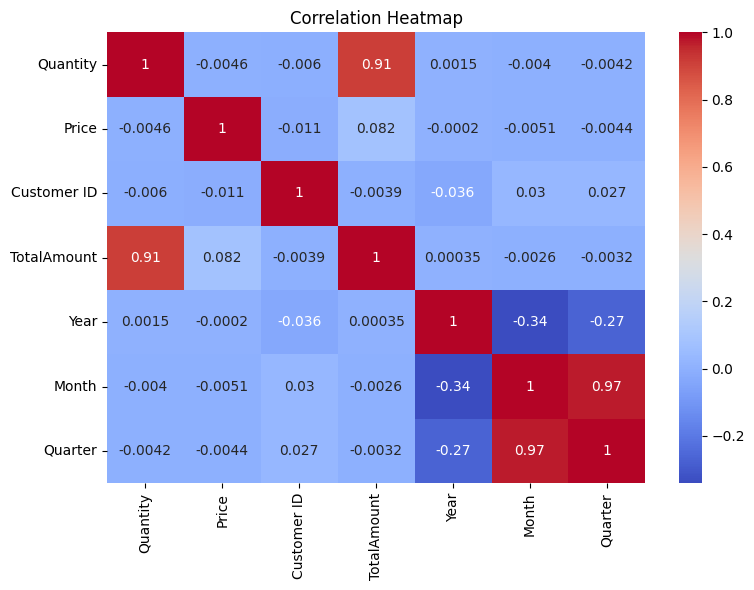

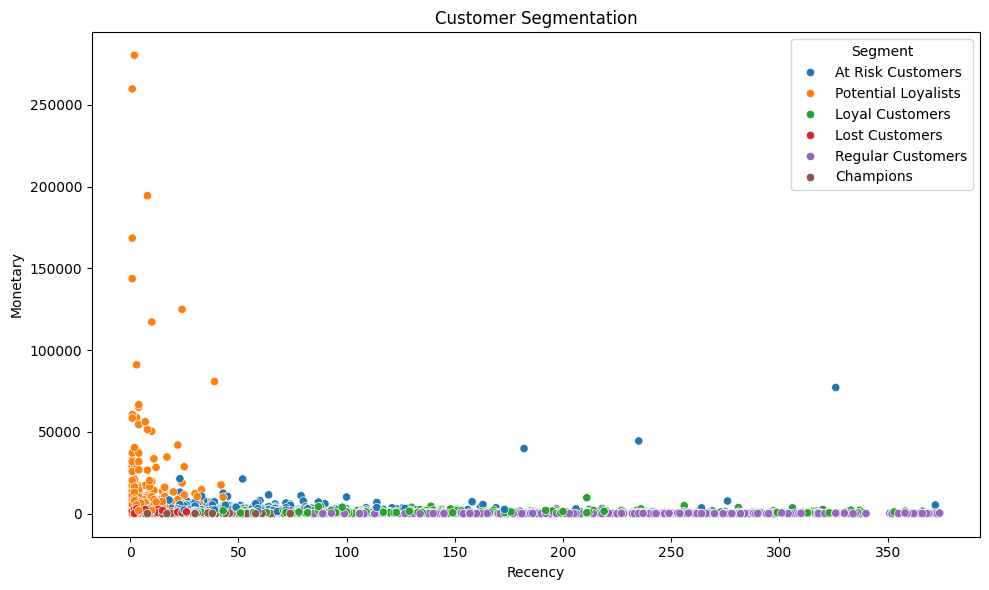

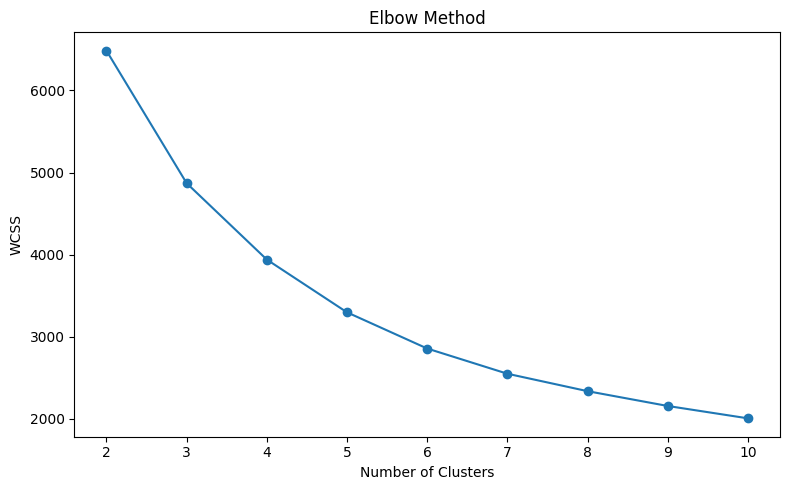

All charts saved successfully!
ZIP File Created: week1_charts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [83]:
# ==========================================
# WEEK 1 CHART GENERATION & DOWNLOAD
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

# ==========================================
# 1. MONTHLY SALES CHART
# ==========================================

monthly_sales = (
    df.groupby('Month')['TotalAmount']
      .sum()
)

plt.figure(figsize=(10,5))

monthly_sales.plot(
    kind='line',
    marker='o'
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig("monthly_sales_chart.png", dpi=300)

plt.show()


# ==========================================
# 2. TOP PRODUCTS CHART
# ==========================================

top_products = (
    df.groupby('Description')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Revenue Generating Products")
plt.xlabel("Products")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig("top_products_chart.png", dpi=300)

plt.show()


# ==========================================
# 3. COUNTRY SALES CHART
# ==========================================

country_sales = (
    df.groupby('Country')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

country_sales.head(10).plot(kind='bar')

plt.title("Top Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig("country_sales_chart.png", dpi=300)

plt.show()


# ==========================================
# 4. TOP CUSTOMERS CHART
# ==========================================

top_customers = (
    df.groupby('Customer ID')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

top_customers.plot(kind='bar')

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig("top_customers_chart.png", dpi=300)

plt.show()


# ==========================================
# 5. CORRELATION HEATMAP
# ==========================================

numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("correlation_heatmap.png", dpi=300)

plt.show()


# ==========================================
# 6. CUSTOMER SEGMENTATION CHART
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Segment',
    palette='tab10'
)

plt.title("Customer Segmentation")

plt.tight_layout()

plt.savefig("customer_segments.png", dpi=300)

plt.show()


# ==========================================
# 7. ELBOW METHOD CHART
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.tight_layout()

plt.savefig("elbow_method.png", dpi=300)

plt.show()


# ==========================================
# CREATE ZIP FILE
# ==========================================

import zipfile

with zipfile.ZipFile(
    "week1_charts.zip",
    "w"
) as zipf:

    zipf.write("monthly_sales_chart.png")
    zipf.write("top_products_chart.png")
    zipf.write("country_sales_chart.png")
    zipf.write("top_customers_chart.png")
    zipf.write("correlation_heatmap.png")
    zipf.write("customer_segments.png")
    zipf.write("elbow_method.png")


print("All charts saved successfully!")
print("ZIP File Created: week1_charts.zip")


# ==========================================
# DOWNLOAD ZIP FILE (GOOGLE COLAB)
# ==========================================

from google.colab import files

files.download("week1_charts.zip")